# Transfer Learning and Smooth Grad Implemenetation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from copy import deepcopy
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset

We will be using pretrained resent18 model trained on imagenet dataset to finetune on CIFAR10 dataset. Then use Smoothgrad to see the Saliency map

## Downloading CIFAR10 dataset

In [ ]:
# download CIFAR10 training and testing datasets, then prepare corresponding dataloaders (batch size = 100)
CIFAR10_train = datasets.CIFAR10("../data", train=True, download=True, transform=transforms.ToTensor())
CIFAR10_test = datasets.CIFAR10("../data", train=False, download=True, transform=transforms.ToTensor())

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

100%|██████████| 170498071/170498071 [00:13<00:00, 12780462.18it/s]


Extracting ../data/cifar-10-python.tar.gz to ../data
Files already downloaded and verified


In [ ]:
print("Classes of dataset:", CIFAR10_train.classes)

Classes of dataset: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


# Resnet Model

In [ ]:
from torchsummary import summary
import torchvision.models as models

resnet18 = models.resnet18(pretrained=True)
# We replace the last layer such that output is just 10 classes
resnet18.fc = torch.nn.Linear(resnet18.fc.in_features, 10)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 59.8MB/s]


Freeze all layers except the last fully connected layer

In [ ]:
for name, param in resnet18.named_parameters():
    if not name.startswith('fc'):  # Last layer is named 'fc'
        param.requires_grad = False

In [ ]:
cf_train_loader = DataLoader(CIFAR10_train, batch_size = 32, shuffle=True, drop_last=True)
cf_test_loader = DataLoader(CIFAR10_test, batch_size = 32, shuffle=False, drop_last=True)

In [ ]:
from tqdm import tqdm

def train(train_loader, model, criterion, opt, n_epoch=10, batch_size =100, validate = False, val_loader = None, verbose=False):
    """Training over the dataset"""
    best_loss = 1e9
    for epoch in range(n_epoch):
        running_loss = 0
        correct = 0
        total_samples = 0
        accuracy = 0
        for i , data in enumerate(train_loader):
            inputs, labels = data
            opt.zero_grad()
            pred = model(inputs.cuda())
            loss = criterion(pred, labels.cuda())

            loss.backward()
            opt.step()

            probabilities = nn.Softmax(dim=1)(pred)
            predicted_label = torch.argmax(probabilities, dim= 1)
            correct += (predicted_label == labels.cuda()).sum().item()
            total_samples += labels.size(0)

            running_loss += loss.item()

        avg_loss = running_loss / (i+1)
        accuracy = (correct/ total_samples)
        if verbose:
            print(f"Epoch:{epoch}, Training_Loss:{avg_loss}, Training Accuracy:{accuracy}")

        if validate:
            val_running_loss = 0
            val_correct = 0
            val_total_samples = 0
            val_accuracy = 0
            for i , data in enumerate(val_loader):
                inputs, labels = data
                opt.zero_grad()
                pred = model(inputs.cuda())
                loss = criterion(pred, labels.cuda())

                probabilities = nn.Softmax(dim=1)(pred)
                predicted_label = torch.argmax(probabilities, dim= 1)
                val_correct += (predicted_label == labels.cuda()).sum().item()
                val_total_samples += labels.size(0)

                val_running_loss += loss.item()

            val_avg_loss = val_running_loss / (i+1)
            val_accuracy = (val_correct/ val_total_samples)
            if verbose:
                print(f"Validation_Loss:{val_avg_loss}, Validation Accuracy:{val_accuracy}")

            if val_avg_loss <best_loss:
                print("Saving")
                torch.save(model.state_dict(), 'model')
                best_loss = val_avg_loss
    print(f"Training_Loss:{avg_loss}, Training Accuracy:{accuracy}")


def evaluate(test_loader, model, criterion, batch_size =100):
    """Evaluation epoch over the dataset"""
    running_loss = 0
    correct = 0
    total_samples = 0
    accuracy = 0
    for i , data in enumerate(test_loader):
        inputs, labels = data
        pred = model(inputs.cuda())
        loss = criterion(pred, labels.cuda())

        probabilities = nn.Softmax(dim=1)(pred)
        predicted_label = torch.argmax(probabilities, dim= 1)
        correct += (predicted_label == labels.cuda()).sum().item()
        total_samples += labels.size(0)

        running_loss += loss.item()

    avg_loss = running_loss / (i+1)
    accuracy = (correct/ total_samples)
    print(f"Test_Loss:{avg_loss}, Test Accuracy:{accuracy}")
    return avg_loss, accuracy


In [ ]:
criterion = torch.nn.CrossEntropyLoss() # computes softmax and then the cross entropy
opt = torch.optim.SGD(resnet18.parameters(), lr=0.2)

In [ ]:
train(cf_train_loader, resnet18.cuda(), criterion, opt, 10, 32, validate = True, val_loader = cf_test_loader,  verbose=True)

Epoch:0, Training_Loss:9.666212975139349, Training Accuracy:0.30329705505761845
Validation_Loss:13.181544044078924, Validation Accuracy:0.26352163461538464
Saving
Epoch:1, Training_Loss:9.391730577478642, Training Accuracy:0.3157010243277849
Validation_Loss:6.250006629106326, Validation Accuracy:0.3659855769230769
Saving
Epoch:2, Training_Loss:9.45294518415815, Training Accuracy:0.3112395966709347
Validation_Loss:8.709282253033075, Validation Accuracy:0.3395432692307692
Epoch:3, Training_Loss:9.454619934097906, Training Accuracy:0.31550096030729835
Validation_Loss:6.976183325816423, Validation Accuracy:0.34154647435897434
Epoch:4, Training_Loss:9.459737972321797, Training Accuracy:0.31514084507042256
Validation_Loss:7.256471527692599, Validation Accuracy:0.33653846153846156
Epoch:5, Training_Loss:9.33302438152279, Training Accuracy:0.31576104353393086
Validation_Loss:7.911675263673831, Validation Accuracy:0.3306290064102564
Epoch:6, Training_Loss:9.375503192027308, Training Accuracy:0.

In [ ]:
resnet18.load_state_dict(torch.load('model'))
evaluate(cf_train_loader, resnet18.cuda(), criterion, 32)
evaluate(cf_test_loader, resnet18.cuda(), criterion, 32)

Test_Loss:0.46682140398078936, Test Accuracy:0.8385683418693982
Test_Loss:0.7593490790384703, Test Accuracy:0.7447916666666666


(0.7593490790384703, 0.7447916666666666)

# Smooth Grad

In [ ]:
random.seed(7)
random_indices = random.sample(range(len(CIFAR10_test)), k=5)
samples = [CIFAR10_test[i] for i in random_indices]

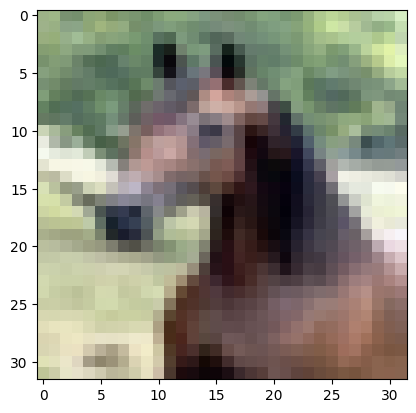

True Label: 7
Pred Label: tensor(7, device='cuda:0')


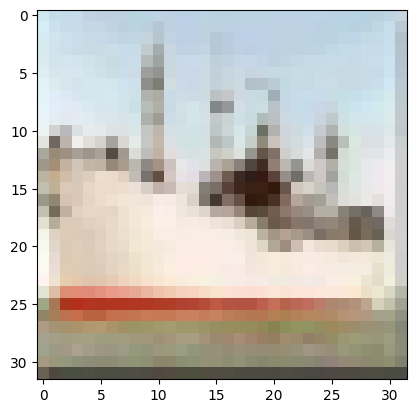

True Label: 8
Pred Label: tensor(8, device='cuda:0')


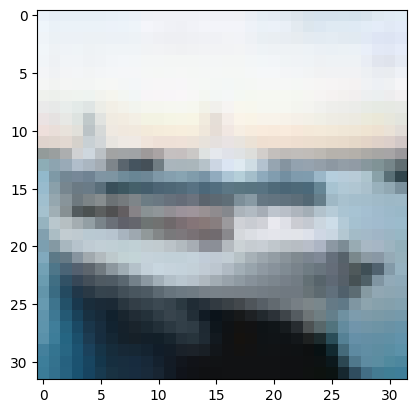

True Label: 8
Pred Label: tensor(8, device='cuda:0')


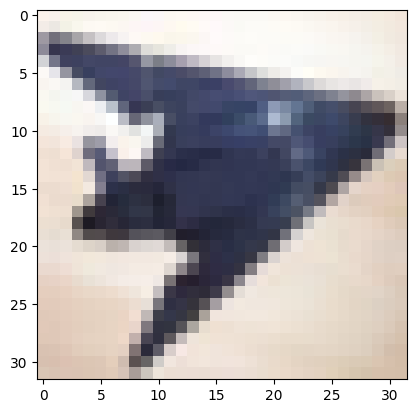

True Label: 0
Pred Label: tensor(0, device='cuda:0')


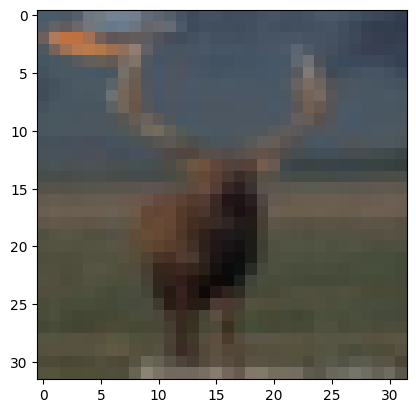

True Label: 4
Pred Label: tensor(4, device='cuda:0')


In [ ]:
resnet18.eval()
for image, label in samples:
    plt.imshow(image.permute(1,2,0))
    plt.show()
    print("True Label:", label)
    pred = torch.argmax(nn.Softmax(dim=1)(resnet18(image.unsqueeze(0).cuda())))
    print("Pred Label:", pred)

## SmoothGrad Computation

In [ ]:
def compute_SmoothGrad(model, X, n_samples, sigma):
    std = sigma * float(torch.max(X) - torch.min(X))
    total_grad = torch.zeros_like(X)
    for n in range(n_samples):
        x_t = X.clone().requires_grad_(True)
        noise_vector = torch.normal(0.0, std, x_t.shape)
        x_t = x_t + noise_vector

        one_hot = torch.zeros(1, 10)

        logits = nn.Softmax(dim=1)(model(x_t.cuda()))
        index = torch.argmax(logits)    # Generate predictions

        one_hot[0][index] = 1
        one_hot = torch.sum(one_hot.cuda() * logits)
        grad = torch.autograd.grad(outputs=one_hot, inputs=x_t)[0]

        total_grad += grad

    avg_gradients = total_grad[0, :, :, :] / n_samples
    return avg_gradients

In [ ]:
from matplotlib import pylab as P
import numpy as np

def ShowGrayscaleImage(im, title='', ax=None):
    if ax is None:
        P.figure()
    P.axis('off')
    P.imshow(im, cmap=P.cm.gray, vmin=0, vmax=1)
    P.title(title)

def VisualizeImageGrayscale(image_3d, percentile=99):
  """Returns a 3D tensor as a grayscale 2D tensor.

  This method sums a 3D tensor across the absolute value of axis=2, and then
  clips values at a given percentile.
  """
  image_2d = np.sum(np.abs(image_3d), axis=2)

  vmax = np.percentile(image_2d, percentile)
  vmin = np.min(image_2d)

  return np.clip((image_2d - vmin) / (vmax - vmin), 0, 1)

def ShowHeatMap(im, title='', ax=None):
    if ax is None:
        P.figure()
    P.axis('off')
    P.imshow(im, cmap='inferno')
    P.title(title)

# Boilerplate methods.
def ShowImage(im, title='', ax=None):
    if ax is None:
        P.figure()
    P.axis('off')
    P.imshow(im)
    P.title(title)

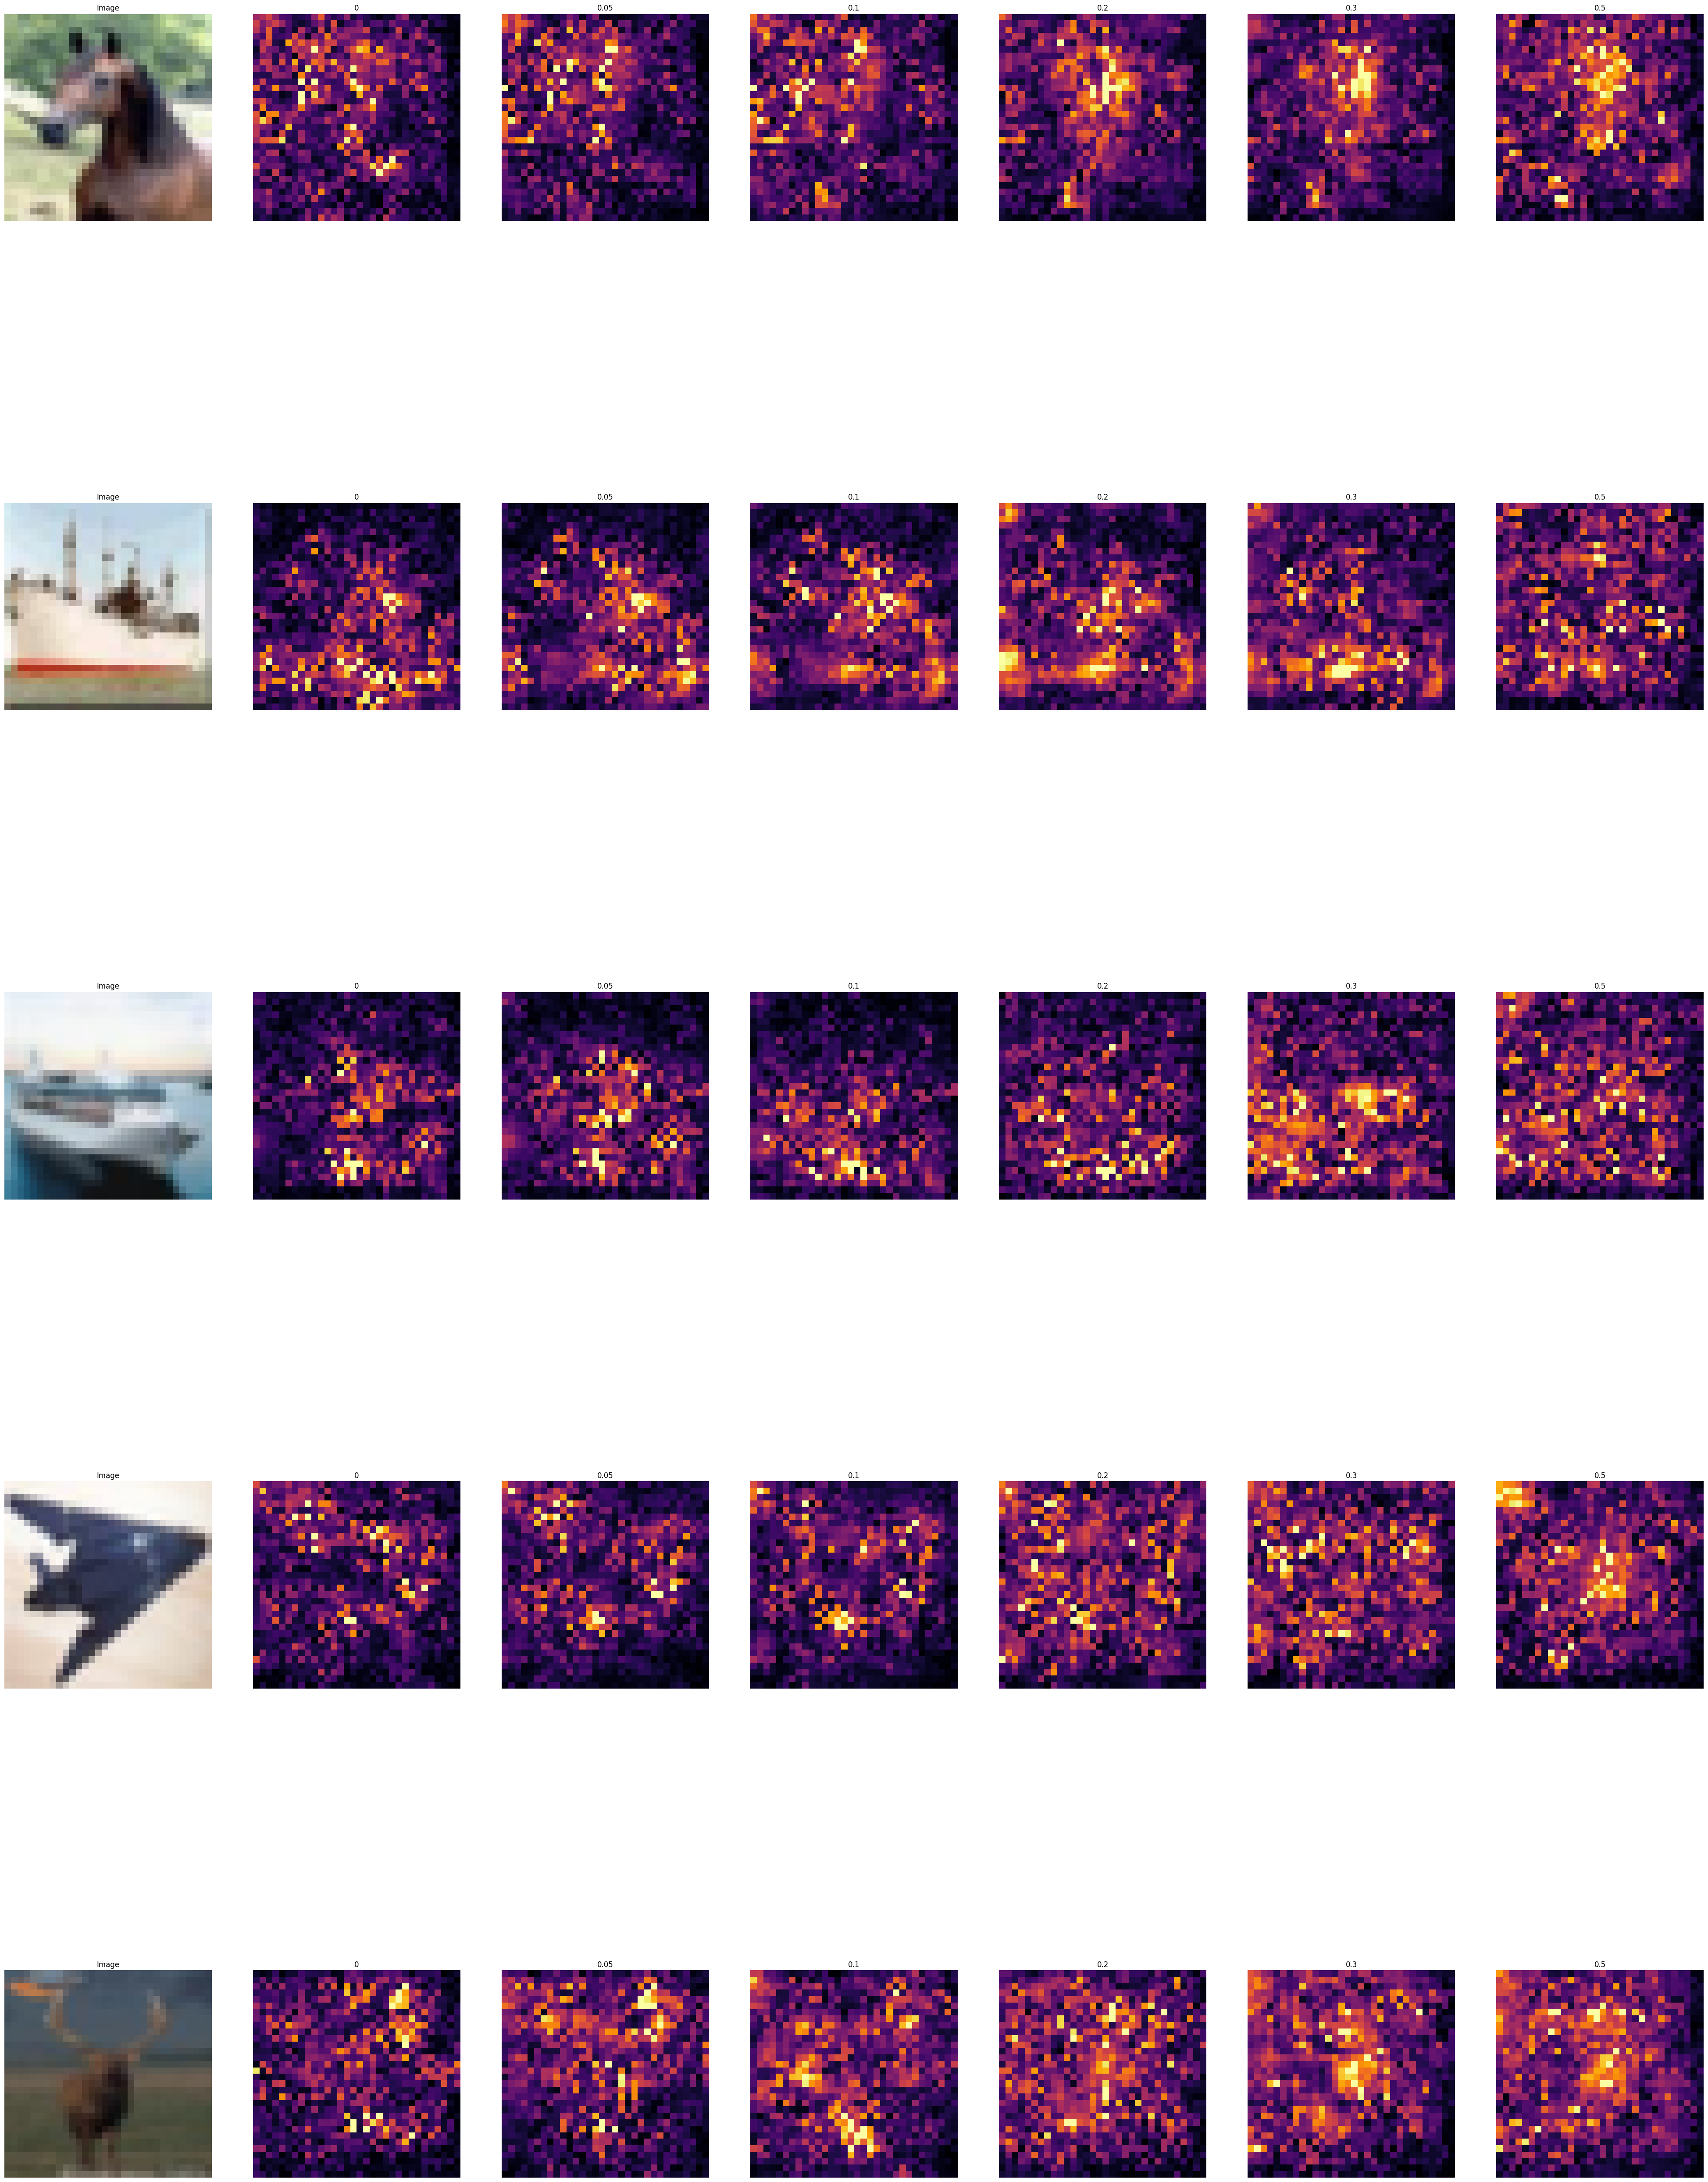

In [ ]:
ROWS = 5
COLS = 7
UPSCALE_FACTOR = 10
P.figure(figsize=(ROWS * UPSCALE_FACTOR, COLS * UPSCALE_FACTOR))

for i in range(len(samples)):
    ShowImage(samples[i][0].permute(1,2,0), "Image", ax=P.subplot(ROWS, COLS, (7*i)+1))
    # Different sigma represent the limit of noise we allow to add
    for j,sigma in enumerate([0, 0.05, 0.1, 0.2, 0.3, 0.5]):
        smooth_grad = compute_SmoothGrad(resnet18, samples[i][0].unsqueeze(0), 50, sigma)
        grad_np = smooth_grad.permute(1,2,0).numpy()
        s_grad_np = VisualizeImageGrayscale(grad_np)
        ShowHeatMap(s_grad_np, f"{sigma}", ax=P.subplot(ROWS, COLS, ((7*i)+(j+2))))